## **Image Data Enrichment - Open CV for fashionMNIST**

The objective of this Python notebook is to compare 6 different image data enrichment techniques on the fashionMNIST dataset, via OpenCV.

The methods used here are:

- No Processing
- Rotation
- Translation
- Scaling
- Noise
- Blur


### **Data Preparation**

This data below is to import the fashionMNIST dataset after the cleaning operation of PCA via openCV, which has the best image cleaning effect after comparison.

In [1]:
import numpy as np
import cv2

from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam


In [2]:
(trainImg, trainLabel), (testImg, testLabel) = fashion_mnist.load_data()
print(trainImg.shape, trainLabel.shape, testImg.shape, testLabel.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [3]:
trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical  = to_categorical(testLabel, 10)


### **Simple RNN Model**

In [4]:

def initRNN():
    model = Sequential([
        SimpleRNN(128, input_shape=(28, 28)),
        Dense(10, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [5]:
def pcaMethod(img2d, n_components=20):
    
    X = img2d.astype(np.float32)
    H, W = X.shape

    mean = np.mean(X, axis=0, keepdims=True)
    Xc = X - mean

    cov = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)

    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]

    k = min(n_components, W)
    P = eigvecs[:, :k]

    Z = Xc @ P
    Xrec = Z @ P.T + mean
    return Xrec.astype(np.float32)


### **Image Data Enrichment Methods**

In [6]:
def augment_cv2(img, mode, rng):
    """
    img: (28,28) float32 in [0,1]
    mode: none|rotation|translation|scaling|noise|blur
    """
    H, W = img.shape

    # Method 1 - No Processing
    if mode == "none":
        out = img

    # Method 2 - Rotation
    elif mode == "rotation":
        angle = rng.uniform(-15, 15)
        M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)
        out = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # Method 3 - Translation
    elif mode == "translation":
        tx = rng.uniform(-0.1, 0.1) * W
        ty = rng.uniform(-0.1, 0.1) * H
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # Method 4 - Scaling
    elif mode == "scaling":
        scale = rng.uniform(0.85, 1.15)
        newW, newH = int(W * scale), int(H * scale)
        resized = cv2.resize(img, (newW, newH), interpolation=cv2.INTER_LINEAR)

        if scale >= 1.0:
            x0 = (newW - W) // 2
            y0 = (newH - H) // 2
            out = resized[y0:y0+H, x0:x0+W]
        else:
            pad_x = (W - newW) // 2
            pad_y = (H - newH) // 2
            out = cv2.copyMakeBorder(
                resized,
                pad_y, H-newH-pad_y,
                pad_x, W-newW-pad_x,
                borderType=cv2.BORDER_REFLECT_101
            )

    # Method 5 - Noise
    elif mode == "noise":
        sigma = rng.uniform(0.02, 0.08)
        noise = rng.normal(0, sigma, size=img.shape).astype(np.float32)
        out = img + noise

    # Method 6 - Blur
    elif mode == "blur":
        k = int(rng.choice([3, 5]))
        out = cv2.GaussianBlur(img, (k, k), sigmaX=0)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return np.clip(out, 0.0, 1.0).astype(np.float32)


### **Model Training and Evaluation**

In [7]:
def comparisonModels(cleaningMethod, augMode="none", seed=42, epochs=5, batch_size=64):
    rng = np.random.default_rng(seed)

    # cleaning
    trainImg2 = np.array([cleaningMethod(img) for img in trainImg], dtype=np.float32)
    testImg2  = np.array([cleaningMethod(img) for img in testImg], dtype=np.float32)

    # normalization
    trainImg2 = (trainImg2 / 255.0).reshape(-1, 28, 28).astype(np.float32)
    testImg2  = (testImg2  / 255.0).reshape(-1, 28, 28).astype(np.float32)

    # enrichment
    if augMode != "none":
        trainImg2 = np.array([augment_cv2(img, augMode, rng) for img in trainImg2], dtype=np.float32)

    # evaluation
    model = initRNN()
    model.fit(trainImg2, trainLabelCategorical, epochs=epochs, batch_size=batch_size, verbose=1)
    return model.evaluate(testImg2, testLabelCategorical, verbose=0)


In [8]:
modes = ["none", "rotation", "translation", "scaling", "noise", "blur"]

results = {}
for m in modes:
    loss, acc = comparisonModels(lambda img: pcaMethod(img, n_components=20), augMode=m)
    results[m] = (loss, acc)
    print(f"{m:12s} -> loss={loss:.4f}, acc={acc:.4f}")


2026-01-01 20:52:05.581951: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-01-01 20:52:05.581985: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-01-01 20:52:05.581991: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-01-01 20:52:05.582017: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-01 20:52:05.582025: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/anaconda3/envs/tfpython39/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequenti

Epoch 1/5


2026-01-01 20:52:05.923483: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


938/938 ━━━━━━━━━━━━━━━━━━━━ 162s 172ms/step - accuracy: 0.6861 - loss: 0.8740
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 161s 172ms/step - accuracy: 0.8126 - loss: 0.5203
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 161s 172ms/step - accuracy: 0.8348 - loss: 0.4577
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 162s 173ms/step - accuracy: 0.8415 - loss: 0.4351
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 163s 173ms/step - accuracy: 0.8454 - loss: 0.4250
none         -> loss=0.4425, acc=0.8398
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 169s 180ms/step - accuracy: 0.6249 - loss: 1.0178
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 168s 179ms/step - accuracy: 0.7595 - loss: 0.6606
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 174s 185ms/step - accuracy: 0.7894 - loss: 0.5802
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 178s 190ms/step - accuracy: 0.8060 - loss: 0.5388
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 172s 183ms/step - accuracy: 0.8076 - loss: 0.5386
rotation     -> loss=0.5186, acc=0.8109
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1

### **Comparison**

In [9]:
import pandas as pd

results_df = pd.DataFrame(
    [
        {
            "Augmentation Method": k,
            "Test Loss": v[0],
            "Test Accuracy": v[1]
        }
        for k, v in results.items()
    ]
)

results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

results_df


,Augmentation Method,Test Loss,Test Accuracy
0,none,0.442461,0.8398
1,scaling,0.462407,0.8307
2,noise,0.474337,0.8300
3,blur,0.500262,0.8239
4,rotation,0.518554,0.8109
5,translation,0.569928,0.7878


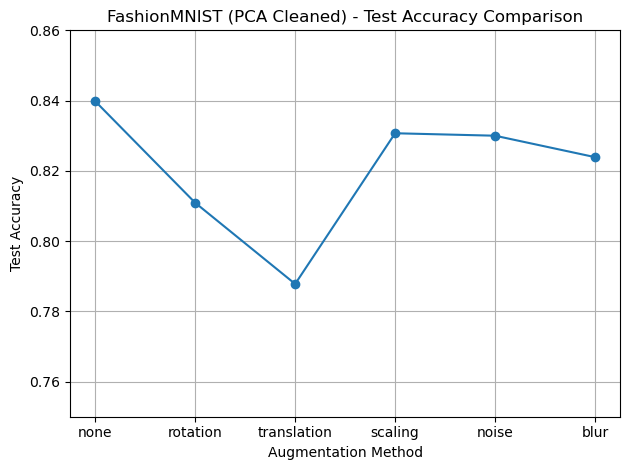

In [10]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Augmentation Method": ["none", "scaling", "noise", "blur", "rotation", "translation"],
    "Test Accuracy": [0.8398, 0.8307, 0.8300, 0.8239, 0.8109, 0.7878],
    "Test Loss": [0.442461, 0.462407, 0.474337, 0.500262, 0.518554, 0.569928]
})

order = ["none", "rotation", "translation", "scaling", "noise", "blur"]
results_df["Augmentation Method"] = pd.Categorical(
    results_df["Augmentation Method"], categories=order, ordered=True
)
results_df = results_df.sort_values("Augmentation Method")

plt.figure()
plt.plot(
    results_df["Augmentation Method"],
    results_df["Test Accuracy"],
    marker="o"
)
plt.xlabel("Augmentation Method")
plt.ylabel("Test Accuracy")
plt.title("FashionMNIST(PCA Cleaned) - Test Accuracy Comparison")
plt.ylim(0.75, 0.86)   
plt.grid(True)
plt.tight_layout()
plt.show()

- The result of line chart indicates that the image enrichment method with the worst effect is the Translation, while the best one is the Scaler, except no processing.
- In addition, the Noise, Rotation and Blur have similar performances.
- With no processing, the experimental results are better than all the other results after data enrichment, because the PCA cleaning has already significantly improved the accuracy of this dataset and has reached its limit, additional data augmentation methods may distort the original data and make it unrecognizable, thereby leading to a decline in accuracy.